# Surface Scattering and BSDF Models

A **BSDF** (Bidirectional Scattering Distribution Function) describes how a
surface redirects light that is not simply refracted or specularly reflected.

| BSDF | Scatter type | Parameters |
|---|---|---|
| Default (`None`) | Specular Fresnel refraction/reflection | -- |
| `SpecularBRDF` | Perfect mirror reflection | -- |
| `LambertianBSDF` | Cosine-weighted diffuse scatter | `reflectance_value` in [0,1] |
| `HarveyShackBSDF` | Micro-roughness scatter (ABg model) | `b0`, `l0`, `s` |
| `TabulatedBSDF` | User-defined lookup table | angles + BRDF values |

Attach one through a `SurfaceConfig`:

```python
SurfaceConfig(bsdf=LambertianBSDF(0.9), scatter_fraction=0.05)
```

Two separate ideas are at work here, and keeping them apart avoids most of the
confusion around scatter models:

- **The BSDF sets the *shape* of the scatter lobe** -- where a scattered ray goes.
- **`scatter_fraction` sets *how much* light is scattered** -- the probability that
  a ray striking the surface is handed to the BSDF at all. The rest continue
  along the ordinary specular or refractive path.

A BSDF **replaces** the specular behaviour for the rays it handles, so
`scatter_fraction=1.0` (the default) turns a surface into a *pure* diffuser
with no transmitted beam left. Real surfaces scatter a small fraction, so a
value well below 1 is usually what you want.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

from optiland.coordinate_system import CoordinateSystem
from optiland.nonsequential import (
    NSQScene, Spectrum,
    CollimatedSourceConfig, PointSourceConfig,
    IrradianceDetectorConfig,
    LensConfig, MirrorConfig,
    SurfaceConfig,
    SpecularBRDF, LambertianBSDF, HarveyShackBSDF,
)

spec = Spectrum.monochromatic(0.55)

## 1. Default Behaviour: Fresnel Refraction

With no BSDF, a refractive surface uses **detached-sample / attached-weight
Fresnel splitting**: each ray is stochastically either refracted or reflected
according to the Fresnel equations, with a throughput weight that keeps the
estimate unbiased (and differentiable on the torch backend). This is the
physically correct treatment for uncoated glass.

At normal incidence N-BK7 reflects about 4% per surface, so a lens with two
uncoated faces transmits roughly 92%.

Note the detector is deliberately made large enough to catch the entire
diverging beam. Sizing it too small removes flux that was transmitted
perfectly well, and the missing light then looks like a surface loss.


Flux in       : 1.0000 W
Flux detected : 0.9166 W
Transmission  : 91.7%
Fresnel loss  : 8.3%  (expected ~8% for two uncoated surfaces)


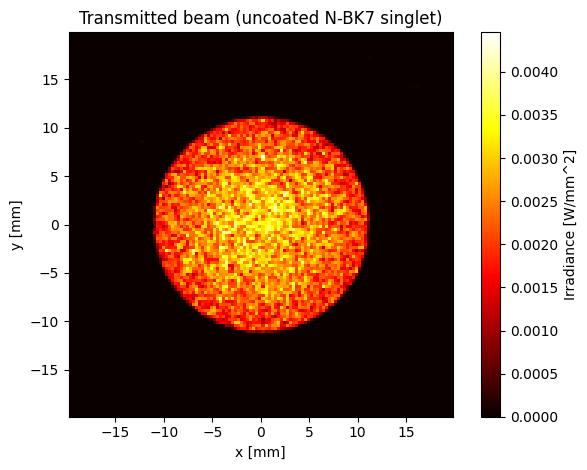

In [2]:
scene = NSQScene()
scene.add_source(
    'S', CoordinateSystem(z=-80),
    CollimatedSourceConfig(spectrum=spec, total_flux=1.0, aperture_radius=10.0),
)
scene.add_lens(
    'L', CoordinateSystem(z=0),
    LensConfig(r1=50, r2=-50, thickness=5, material='N-BK7', front_aperture_radius=12.5),
)
# 40 mm across: past focus the beam has spread to ~21 mm diameter, so a
# 20 mm detector would clip it and understate the transmission.
scene.add_detector(
    'D', CoordinateSystem(z=100),
    IrradianceDetectorConfig(width=40, height=40, num_pixels_x=128, num_pixels_y=128),
)

result = scene.trace(num_rays=50_000, seed=42)
irr = result.detectors['D']

transmission = irr.total_flux / result.total_flux_in * 100
print(f"Flux in       : {result.total_flux_in:.4f} W")
print(f"Flux detected : {irr.total_flux:.4f} W")
print(f"Transmission  : {transmission:.1f}%")
print(f"Fresnel loss  : {100 - transmission:.1f}%  (expected ~8% for two uncoated surfaces)")

fig = irr.plot(cmap='hot')
plt.title('Transmitted beam (uncoated N-BK7 singlet)')
plt.tight_layout()
plt.show()


## 2. SpecularBRDF: Perfect Mirror

`SpecularBRDF` reflects every ray about the surface normal with no loss and no
spread. It is useful for an idealised mirror.

The mirror below is concave toward the incoming beam, which is expressed by a
**negative radius** (centre of curvature on the -z side). No rotation is
needed; adding one would flip it to convex and diverge the beam.

`MirrorConfig.reflectance` has no implicit default and is a required
argument -- a mirror built without one raises, so a scene never silently gets
a 100% reflector. Here it is set to `1.0` deliberately, since the point of
this section is to isolate the *directional* behaviour of `SpecularBRDF` from
any flux loss; a real mirror coating would use a lower value (see the
`MirrorConfig` docstring for constants, wavelength-dependent callables, or
`optiland.coatings` objects).

Flux on detector: 1.0000 W of 1.0 W


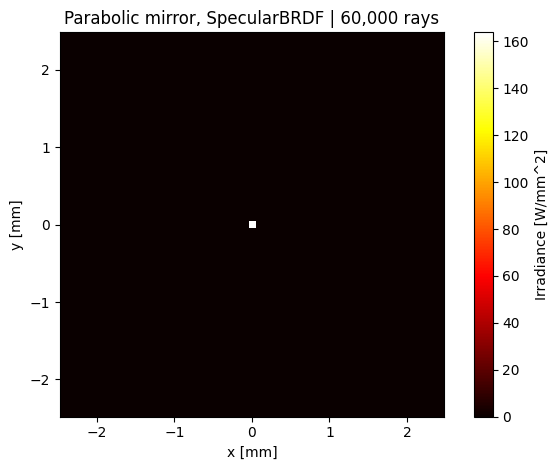

In [3]:
# Parabolic mirror, f = |radius| / 2 = 100 mm
scene_spec = NSQScene()
scene_spec.add_source(
    'S', CoordinateSystem(z=-80),
    CollimatedSourceConfig(spectrum=spec, total_flux=1.0, aperture_radius=15.0),
)
scene_spec.add_mirror(
    'M', CoordinateSystem(z=0),
    MirrorConfig(radius=-200, conic=-1.0, aperture_radius=20.0, reflectance=1.0,
                 surface=SurfaceConfig(bsdf=SpecularBRDF())),
)
scene_spec.add_detector(
    'D', CoordinateSystem(z=-100),   # at the focus
    IrradianceDetectorConfig(width=5, height=5, num_pixels_x=128, num_pixels_y=128),
)

result_spec = scene_spec.trace(num_rays=60_000, seed=42)
irr_spec = result_spec.detectors['D']

print(f"Flux on detector: {irr_spec.total_flux:.4f} W of {result_spec.total_flux_in:.1f} W")

fig = irr_spec.plot(cmap='hot')
plt.title(f'Parabolic mirror, SpecularBRDF | {irr_spec.num_rays_hit:,} rays')
plt.tight_layout()
plt.show()

## 3. LambertianBSDF: Diffuse Scatter

`LambertianBSDF(reflectance_value)` scatters rays into a **cosine-weighted**
hemisphere about the surface normal, the standard model for a matte surface.
`reflectance_value` scales the flux of each scattered ray, so 0.9 means 10% is
absorbed at the scatter event.

Because the scatter is built about the normal facing the incoming ray, a
diffuse surface sends light **back** toward the source: it is a diffuse
*reflector*, not a diffuser you can see through.

`scatter_fraction` decides how much of the beam is treated this way. Below, the
back face of a lens scatters a varying fraction and refracts the rest, so the
transmitted beam and the back-scattered light trade off against each other.


scatter_fraction= 0.0 -> forward 0.916 W, back-scattered 0.080 W


scatter_fraction= 0.1 -> forward 0.823 W, back-scattered 0.102 W


scatter_fraction= 0.3 -> forward 0.643 W, back-scattered 0.149 W


scatter_fraction= 0.6 -> forward 0.368 W, back-scattered 0.236 W


scatter_fraction= 1.0 -> forward 0.000 W, back-scattered 0.384 W


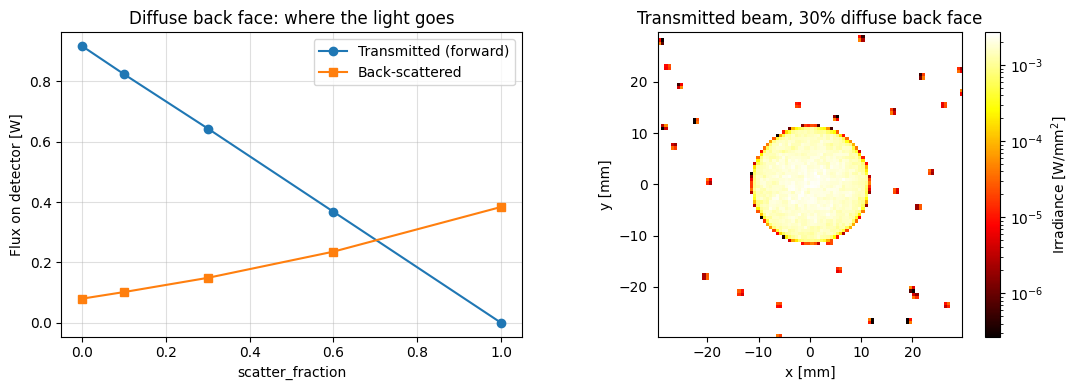

In [4]:
lambertian = LambertianBSDF(reflectance_value=0.9)


def trace_scatter(fraction, n_rays=40_000):
    """Lens whose back face scatters `fraction` of the light diffusely."""
    scene_l = NSQScene()
    scene_l.add_source(
        'S', CoordinateSystem(z=-80),
        CollimatedSourceConfig(spectrum=spec, total_flux=1.0, aperture_radius=10.0),
    )
    scene_l.add_lens(
        'L', CoordinateSystem(z=0),
        LensConfig(
            r1=50, r2=-50, thickness=5, material='N-BK7',
            front_aperture_radius=12.5,
            back=SurfaceConfig(bsdf=lambertian, scatter_fraction=fraction),
        ),
    )
    # Forward detector past the focus, backward detector behind the source
    scene_l.add_detector(
        'D_fwd', CoordinateSystem(z=100),
        IrradianceDetectorConfig(width=60, height=60, num_pixels_x=96, num_pixels_y=96),
    )
    scene_l.add_detector(
        'D_bwd', CoordinateSystem(z=-90),
        IrradianceDetectorConfig(width=200, height=200, num_pixels_x=96, num_pixels_y=96),
    )
    res = scene_l.trace(num_rays=n_rays, seed=42)
    return res.detectors['D_fwd'], res.detectors['D_bwd']


fractions = [0.0, 0.1, 0.3, 0.6, 1.0]
fwd_flux, bwd_flux = [], []
for f in fractions:
    fwd, bwd = trace_scatter(f)
    fwd_flux.append(fwd.total_flux)
    bwd_flux.append(bwd.total_flux)
    print(f"scatter_fraction={f:4.1f} -> forward {fwd.total_flux:.3f} W, "
          f"back-scattered {bwd.total_flux:.3f} W")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(fractions, fwd_flux, 'o-', label='Transmitted (forward)')
ax.plot(fractions, bwd_flux, 's-', label='Back-scattered')
ax.set_xlabel('scatter_fraction')
ax.set_ylabel('Flux on detector [W]')
ax.set_title('Diffuse back face: where the light goes')
ax.legend()
ax.grid(True, alpha=0.4)

# Spatial picture at a 30% scatter fraction
fwd30, _ = trace_scatter(0.3)
ax = axes[1]
im = ax.imshow(fwd30.irradiance, origin='lower', cmap='hot',
               extent=[fwd30.x_coords[0], fwd30.x_coords[-1],
                       fwd30.y_coords[0], fwd30.y_coords[-1]],
               norm=LogNorm(vmin=fwd30.irradiance.max() * 1e-4,
                            vmax=fwd30.irradiance.max()))
plt.colorbar(im, ax=ax, label='Irradiance [W/mm$^2$]')
ax.set_title('Transmitted beam, 30% diffuse back face')
ax.set_xlabel('x [mm]')
ax.set_ylabel('y [mm]')

plt.tight_layout()
plt.show()


## 4. HarveyShackBSDF: Micro-Roughness Scatter

The **Harvey-Shack ABg model** describes scatter from a polished surface's
residual micro-roughness. It is written in *direction-cosine* space:

$$\mathrm{BSDF}\left(|\beta - \beta_0|\right) = \frac{b_0}{1 + \left(|\beta - \beta_0| / l_0\right)^{s}}$$

where $\beta_0$ is the specular direction and $\beta$ the scattered one.

- `b0` sets the scatter level at the specular peak
- `l0` is the break frequency, i.e. the **angular width** of the lobe
- `s` is the roll-off exponent: larger means the tail falls away faster

Two separate quantities follow from these parameters:

- The **lobe shape**, which the BSDF samples directly.
- The **total integrated scatter (TIS)**, available as
  `bsdf.total_integrated_scatter`. This is the fraction of incident power a
  real surface with these parameters would scatter, and is the natural value
  for `scatter_fraction`.

A polished mirror has a TIS of order $10^{-5}$, so essentially all light stays
specular and the scatter forms a faint halo around a bright core, exactly the
veiling glare that limits contrast in real instruments.


polished : l0=0.005  TIS=9.41e-06
rough    : l0=0.05   TIS=1.61e-03


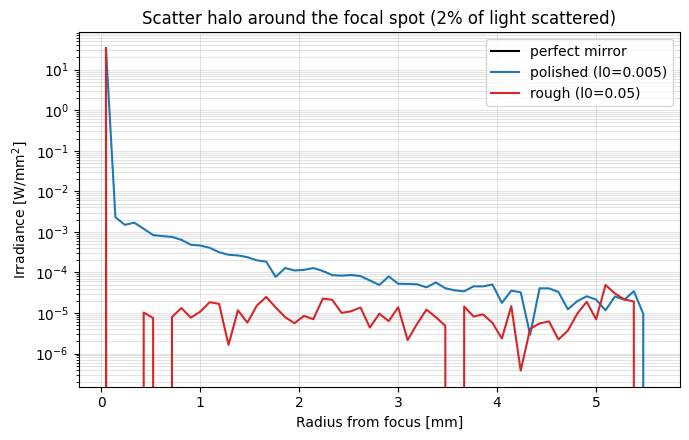

In [5]:
polished = HarveyShackBSDF(b0=1e-2, l0=0.005, s=2.0)   # tight lobe
rough    = HarveyShackBSDF(b0=1e-2, l0=0.05,  s=1.5)   # broad lobe

for name, bsdf in [('polished', polished), ('rough', rough)]:
    print(f"{name:9s}: l0={bsdf.l0:<6} TIS={bsdf.total_integrated_scatter:.2e}")


def mirror_with_scatter(bsdf, fraction, n_rays=200_000):
    """Parabolic mirror whose surface scatters `fraction` of the light."""
    scene_m = NSQScene()
    scene_m.add_source(
        'S', CoordinateSystem(z=-80),
        CollimatedSourceConfig(spectrum=spec, total_flux=1.0, aperture_radius=15.0),
    )
    scene_m.add_mirror(
        'M', CoordinateSystem(z=0),
        MirrorConfig(radius=-200, conic=-1.0, aperture_radius=20.0, reflectance=1.0,
                     surface=SurfaceConfig(bsdf=bsdf, scatter_fraction=fraction)),
    )
    scene_m.add_detector(
        'D', CoordinateSystem(z=-100),
        IrradianceDetectorConfig(width=8, height=8, num_pixels_x=160, num_pixels_y=160),
    )
    return scene_m.trace(num_rays=n_rays, seed=42).detectors['D']


def radial_profile(irr):
    """Azimuthally averaged irradiance versus radius."""
    X, Y = np.meshgrid(irr.x_coords, irr.y_coords)
    R = np.hypot(X, Y).ravel()
    E = irr.irradiance.ravel()
    bins = np.linspace(0, R.max(), 60)
    idx = np.digitize(R, bins) - 1
    prof = np.array([E[idx == k].mean() if np.any(idx == k) else np.nan
                     for k in range(len(bins) - 1)])
    return 0.5 * (bins[:-1] + bins[1:]), prof


# 2% scattered so the halo is visible above Monte Carlo noise; a real polished
# mirror would use scatter_fraction = bsdf.total_integrated_scatter.
fig, ax = plt.subplots(figsize=(7, 4.5))
for label, bsdf, colour in [('perfect mirror', None, 'k'),
                            ('polished (l0=0.005)', polished, 'tab:blue'),
                            ('rough (l0=0.05)', rough, 'tab:red')]:
    irr_m = (mirror_with_scatter(bsdf, 0.02) if bsdf is not None
             else mirror_with_scatter(SpecularBRDF(), 0.0))
    r, prof = radial_profile(irr_m)
    ax.semilogy(r, prof, color=colour, label=label)

ax.set_xlabel('Radius from focus [mm]')
ax.set_ylabel('Irradiance [W/mm$^2$]')
ax.set_title('Scatter halo around the focal spot (2% of light scattered)')
ax.legend()
ax.grid(True, alpha=0.35, which='both')
plt.tight_layout()
plt.show()

## 5. Inspecting a BSDF Directly

Every BSDF exposes
`sample(num_rays, incident_dirs, normals, wavelengths, rng, ray_id, bounce)`,
returning `(scattered_dirs, flux_weights, transmitted)`. Calling it yourself
is the clearest way to see what a model does, with no scene geometry in the
way.

`rng` is an `NSQRng` -- the engine's keyed PCG32 (see the developer guide's
Reproducibility section), not a plain `numpy.random.Generator`: every draw is
a pure function of `(seed, ray_id, bounce, event_slot)`, so `ray_id` and
`bounce` must be supplied per sample. Below, each of the `N_SAMPLES` calls
gets its own `ray_id` (`bounce=0` throughout) so every draw is independent.

Below, a beam travelling along $+z$ strikes a surface whose normal faces $-z$,
so the specular direction is $-z$ and the polar angle $\theta$ is measured from
it.

For a Lambertian surface the density of scattered rays over $\theta$ is

$$p(\theta) = \sin(2\theta), \qquad \langle\cos\theta\rangle = \tfrac{2}{3}$$

which peaks at 45 degrees. This is the signature of **cosine weighting**: a
uniform hemisphere would instead give $p(\theta) = \sin\theta$ and
$\langle\cos\theta\rangle = 1/2$.

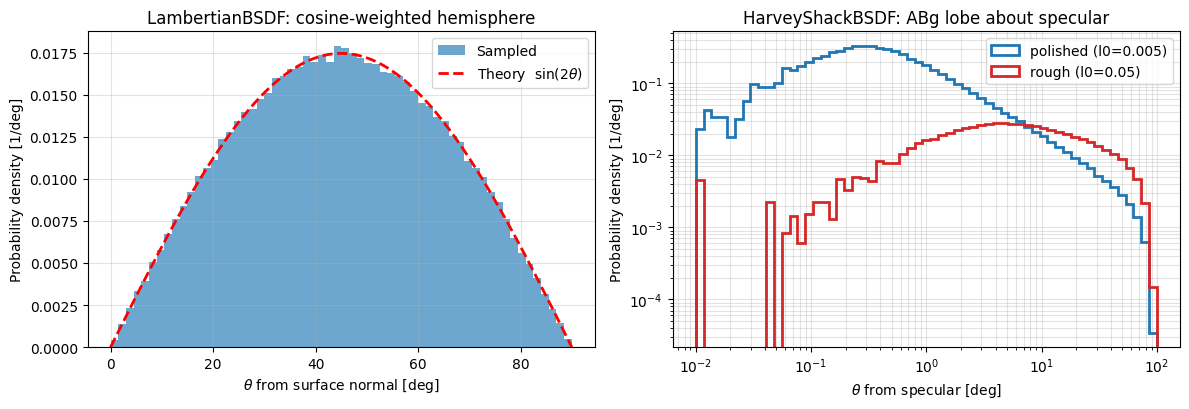

Lambertian <cos(theta)> = 0.6673 (exact 2/3 = 0.6667)


In [6]:
from optiland.nonsequential import NSQRng

rng = NSQRng(seed=0)
N_SAMPLES = 200_000

# Beam along +z hitting a surface whose normal faces -z: specular is -z.
incident = np.tile([0.0, 0.0, 1.0], (N_SAMPLES, 1))
normals = np.tile([0.0, 0.0, -1.0], (N_SAMPLES, 1))
wavelengths = np.full(N_SAMPLES, 0.55)
# A distinct ray_id per sample (bounce=0 throughout) is what makes every draw
# independent under NSQRng's keyed PCG32.
ray_id = np.arange(N_SAMPLES)
bounce = np.zeros(N_SAMPLES, dtype=np.int64)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# ---- Lambertian: cosine-weighted, peaking at 45 degrees --------------------
dirs_lam, _, _ = LambertianBSDF(1.0).sample(
    N_SAMPLES, incident, normals, wavelengths, rng, ray_id, bounce
)
theta_lam = np.degrees(np.arccos(np.clip(-np.asarray(dirs_lam)[:, 2], -1.0, 1.0)))

ax = axes[0]
ax.hist(theta_lam, bins=60, range=(0, 90), density=True,
        alpha=0.65, label='Sampled')
theta_ref = np.linspace(0, 90, 200)
# sin(2*theta) expressed as a density per degree
ax.plot(theta_ref, np.sin(2 * np.radians(theta_ref)) * np.pi / 180,
        'r--', lw=2, label=r'Theory  $\sin(2\theta)$')
ax.set_xlabel(r'$\theta$ from surface normal [deg]')
ax.set_ylabel('Probability density [1/deg]')
ax.set_title('LambertianBSDF: cosine-weighted hemisphere')
ax.legend()
ax.grid(True, alpha=0.35)

# ---- Harvey-Shack: narrow lobe about the specular direction ----------------
ax = axes[1]
for label, bsdf, colour in [('polished (l0=0.005)', polished, 'tab:blue'),
                            ('rough (l0=0.05)', rough, 'tab:red')]:
    dirs_hs, _, _ = bsdf.sample(N_SAMPLES, incident, normals, wavelengths, rng, ray_id, bounce)
    theta_hs = np.degrees(np.arccos(np.clip(-np.asarray(dirs_hs)[:, 2], -1.0, 1.0)))
    ax.hist(theta_hs, bins=np.logspace(-2, 2, 60), density=True,
            histtype='step', lw=2, color=colour, label=label)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\theta$ from specular [deg]')
ax.set_ylabel('Probability density [1/deg]')
ax.set_title('HarveyShackBSDF: ABg lobe about specular')
ax.legend()
ax.grid(True, alpha=0.35, which='both')

plt.tight_layout()
plt.show()

print(f"Lambertian <cos(theta)> = {np.mean(np.cos(np.radians(theta_lam))):.4f} "
      f"(exact 2/3 = {2 / 3:.4f})")

## 6. Transmissive Lambertian: a Diffuser You Can See Through

Section 3's diffuse back face only ever sent light **back** toward the
source, because the scatter lobe was built about the normal facing the
incoming ray. `LambertianBSDF` has a second parameter,
`transmissive_fraction`, that changes this: it is the probability that a
given scatter event samples the hemisphere on the **far side** of the
surface (built about `-normal`) instead of the near side. This is the
model for a real diffuser you look *through* -- ground glass, an
engineered diffuser, a translucent shade -- rather than a diffuse mirror.

- `transmissive_fraction=0.0` (the default, used implicitly in section 3):
  every scatter event lands in the reflective hemisphere.
- `transmissive_fraction=1.0`: every scatter event lands in the
  transmissive hemisphere -- light passes through the surface, spread into
  a cosine-weighted cone instead of continuing along the specular
  refraction direction.

Both extremes below use the same lens back face with `scatter_fraction=1.0`
(a *pure* diffuser, no direct beam left) so the only thing that changes is
which hemisphere the light ends up in.

transmissive_fraction=0.0 (reflector) : forward 0.000 W, backward 0.415 W
transmissive_fraction=1.0 (transmitter): forward 0.159 W, backward 0.041 W

Forward is exactly 0 W in the reflector case: scatter_fraction=1.0 means the back face has no direct specular path left, so nothing reaches D_fwd on axis.
Backward is nonzero (~0.04 W) even in the transmitter case: that is the front face's own ~4% Fresnel reflection (section 1), unrelated to the back-face BSDF, so it shows up on D_bwd regardless of transmissive_fraction.
Forward flux in the transmitter case is far below the ~0.87 W actually leaving the back face diffusely: a cosine-weighted lobe spans a full hemisphere, so most of it misses even an 80 mm-wide detector 95 mm away -- a real design would either use a much larger/closer collector or accept that a diffuser trades a tight beam for one that can be seen from a wide range of angles.


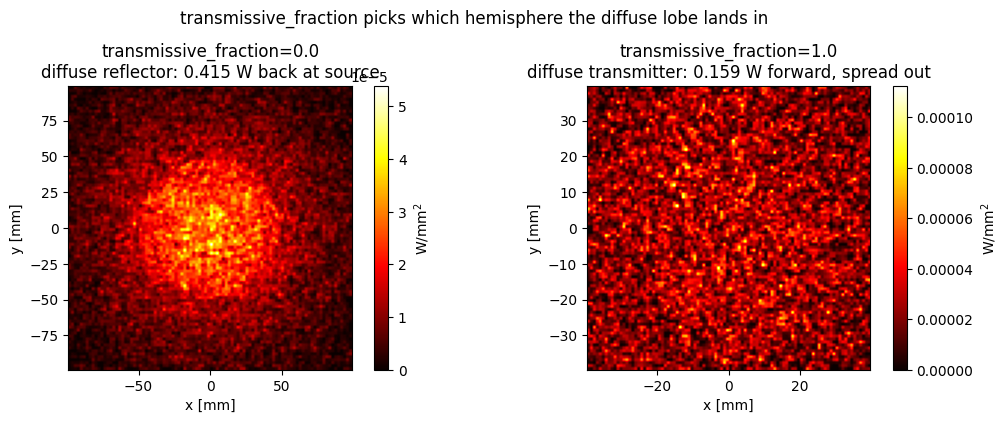

In [7]:
def trace_transmissive(transmissive_fraction, n_rays=60_000):
    """Lens whose back face is a pure diffuser, split between the
    reflective and transmissive hemispheres by `transmissive_fraction`."""
    diffuser = LambertianBSDF(reflectance_value=0.95,
                              transmissive_fraction=transmissive_fraction)
    scene_t = NSQScene()
    scene_t.add_source(
        'S', CoordinateSystem(z=-80),
        CollimatedSourceConfig(spectrum=spec, total_flux=1.0, aperture_radius=10.0),
    )
    scene_t.add_lens(
        'L', CoordinateSystem(z=0),
        LensConfig(
            r1=50, r2=-50, thickness=5, material='N-BK7',
            front_aperture_radius=12.5,
            back=SurfaceConfig(bsdf=diffuser, scatter_fraction=1.0),
        ),
    )
    scene_t.add_detector(
        'D_fwd', CoordinateSystem(z=100),
        IrradianceDetectorConfig(width=80, height=80, num_pixels_x=96, num_pixels_y=96),
    )
    scene_t.add_detector(
        'D_bwd', CoordinateSystem(z=-90),
        IrradianceDetectorConfig(width=200, height=200, num_pixels_x=96, num_pixels_y=96),
    )
    res = scene_t.trace(num_rays=n_rays, seed=42)
    return res.detectors['D_fwd'], res.detectors['D_bwd']


fwd_reflect, bwd_reflect = trace_transmissive(0.0)   # diffuse reflector
fwd_transmit, bwd_transmit = trace_transmissive(1.0)  # diffuse transmitter

print(f"transmissive_fraction=0.0 (reflector) : forward {fwd_reflect.total_flux:.3f} W, "
      f"backward {bwd_reflect.total_flux:.3f} W")
print(f"transmissive_fraction=1.0 (transmitter): forward {fwd_transmit.total_flux:.3f} W, "
      f"backward {bwd_transmit.total_flux:.3f} W")
print()
print("Forward is exactly 0 W in the reflector case: scatter_fraction=1.0 means the "
      "back face has no direct specular path left, so nothing reaches D_fwd on axis.")
print("Backward is nonzero (~0.04 W) even in the transmitter case: that is the front "
      "face's own ~4% Fresnel reflection (section 1), unrelated to the back-face BSDF, "
      "so it shows up on D_bwd regardless of transmissive_fraction.")
print("Forward flux in the transmitter case is far below the ~0.87 W actually leaving "
      "the back face diffusely: a cosine-weighted lobe spans a full hemisphere, so most "
      "of it misses even an 80 mm-wide detector 95 mm away -- a real design would either "
      "use a much larger/closer collector or accept that a diffuser trades a tight beam "
      "for one that can be seen from a wide range of angles.")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
im0 = axes[0].imshow(bwd_reflect.irradiance, origin='lower', cmap='hot', aspect='equal',
                     extent=[bwd_reflect.x_coords[0], bwd_reflect.x_coords[-1],
                             bwd_reflect.y_coords[0], bwd_reflect.y_coords[-1]])
plt.colorbar(im0, ax=axes[0], label='W/mm$^2$')
axes[0].set_title(f'transmissive_fraction=0.0\ndiffuse reflector: {bwd_reflect.total_flux:.3f} W back at source')
axes[0].set_xlabel('x [mm]'); axes[0].set_ylabel('y [mm]')

im1 = axes[1].imshow(fwd_transmit.irradiance, origin='lower', cmap='hot', aspect='equal',
                     extent=[fwd_transmit.x_coords[0], fwd_transmit.x_coords[-1],
                             fwd_transmit.y_coords[0], fwd_transmit.y_coords[-1]])
plt.colorbar(im1, ax=axes[1], label='W/mm$^2$')
axes[1].set_title(f'transmissive_fraction=1.0\ndiffuse transmitter: {fwd_transmit.total_flux:.3f} W forward, spread out')
axes[1].set_xlabel('x [mm]'); axes[1].set_ylabel('y [mm]')

plt.suptitle('transmissive_fraction picks which hemisphere the diffuse lobe lands in', fontsize=12)
plt.tight_layout()
plt.show()

## Summary

- Refractive surfaces use probabilistic Fresnel splitting by default; no BSDF needed
- `SpecularBRDF()` reflects perfectly, with no spread; a mirror's `reflectance` is
  always required -- there is no implicit perfect-mirror default
- `LambertianBSDF(reflectance_value)` scatters into a cosine-weighted hemisphere
  about the normal, so by default it reflects light *back* toward the source
- `LambertianBSDF(..., transmissive_fraction=f)` sends that fraction of scatter
  events into the far-side hemisphere instead, modelling a diffuser you can see
  *through* rather than a diffuse mirror
- `HarveyShackBSDF(b0, l0, s)` samples the ABg lobe about the specular direction;
  `l0` sets the lobe width and `total_integrated_scatter` gives the physical
  scatter level
- A BSDF **replaces** the specular path for the rays it handles. Use
  `SurfaceConfig(bsdf=..., scatter_fraction=f)` to hand it only a fraction `f`
  of the light and keep the rest specular, which is what a real partially
  scattering surface does
- Call `bsdf.sample(num_rays, incident_dirs, normals, wavelengths, rng, ray_id, bounce)`
  directly to inspect a model's lobe without a scene